In [1]:
from pathlib import Path
from collections import Counter
from PIL import Image
import pandas as pd
import torch

DATA_DIR = Path("../data")   # adapte si besoin

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print("Device :", device)

Device : cpu


In [2]:
# Arborescence (dossiers + nb de fichiers par extension)
print("=== Arborescence de data/ ===")
for p in sorted(DATA_DIR.rglob("*")):
    if p.is_dir():
        exts = Counter(f.suffix.lower() for f in p.iterdir() if f.is_file())
        rel = p.relative_to(DATA_DIR)
        print(f"{rel}/  ->  {dict(exts)}")

# Fichiers de labels / métadonnées éventuels (csv, txt, json)
print("\n=== Fichiers tabulaires / métadonnées ===")
for p in DATA_DIR.rglob("*"):
    if p.suffix.lower() in {".csv", ".txt", ".json", ".xlsx"}:
        print(p.relative_to(DATA_DIR))

# Aperçu d'une image
imgs = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
print(f"\nTotal images trouvées : {len(imgs)}")
if imgs:
    im = Image.open(imgs[0])
    print("Exemple :", imgs[0].name, "| taille :", im.size, "| mode :", im.mode)

=== Arborescence de data/ ===
avec_labels/  ->  {}
avec_labels\cancer/  ->  {'.jpg': 50}
avec_labels\normal/  ->  {'.jpg': 50}
sans_label/  ->  {'.jpg': 1406}

=== Fichiers tabulaires / métadonnées ===

Total images trouvées : 1506
Exemple : 05340cd4-3bb2-459d-9937-bf27d52d8351.jpg | taille : (512, 512) | mode : RGB


In [3]:
import numpy as np

DATA_DIR = Path("../data")
OUT_DIR = Path("../outputs"); OUT_DIR.mkdir(exist_ok=True)

rows = []
for p in DATA_DIR.rglob("*.jpg"):
    parts = p.relative_to(DATA_DIR).parts
    if parts[0] == "avec_labels":
        rows.append({"path": str(p), "split": "labeled", "label": parts[1]})
    elif parts[0] == "sans_label":
        rows.append({"path": str(p), "split": "unlabeled", "label": None})

df = pd.DataFrame(rows).sort_values("path").reset_index(drop=True)
df.to_csv(OUT_DIR / "inventory.csv", index=False)

print(df.groupby(["split", "label"], dropna=False).size())
print("\nTotal :", len(df))

split      label 
labeled    cancer      50
           normal      50
unlabeled  NaN       1406
dtype: int64

Total : 1506


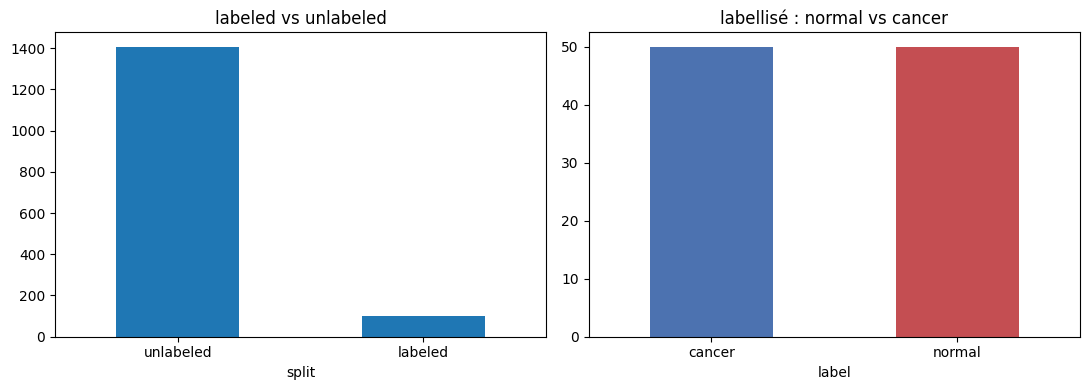

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["split"].value_counts().plot.bar(ax=axes[0], title="labeled vs unlabeled", rot=0)
df[df.split=="labeled"]["label"].value_counts().plot.bar(
    ax=axes[1], title="labellisé : normal vs cancer", rot=0, color=["#4c72b0", "#c44e52"])
plt.tight_layout(); plt.show()

In [6]:
from collections import Counter

sizes, modes = Counter(), Counter()
for p in df["path"]:
    with Image.open(p) as im:
        sizes[im.size] += 1
        modes[im.mode] += 1
print("Tailles :", dict(sizes))
print("Modes   :", dict(modes))

def is_grayscale(path):
    arr = np.asarray(Image.open(path))
    if arr.ndim == 2:
        return True
    return np.allclose(arr[..., 0], arr[..., 1]) and np.allclose(arr[..., 1], arr[..., 2])

sample = df.sample(30, random_state=0)["path"]
print("\nÉchantillon (30 imgs) : niveaux de gris dupliqué (R=G=B) ?",
      all(is_grayscale(p) for p in sample))

Tailles : {(512, 512): 1506}
Modes   : {'RGB': 1506}

Échantillon (30 imgs) : niveaux de gris dupliqué (R=G=B) ? True


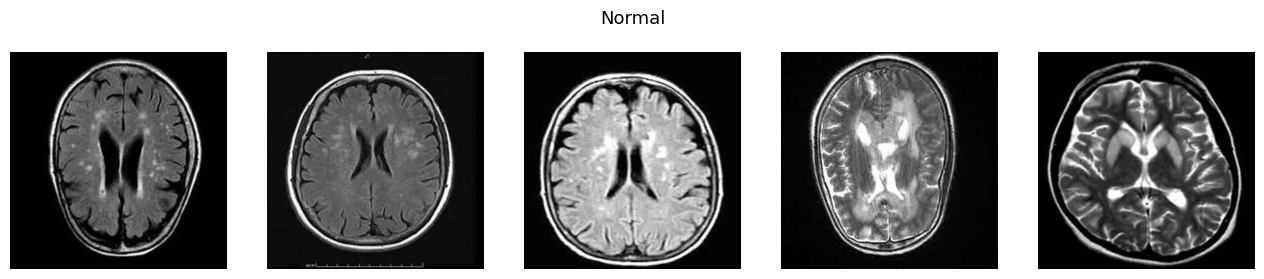

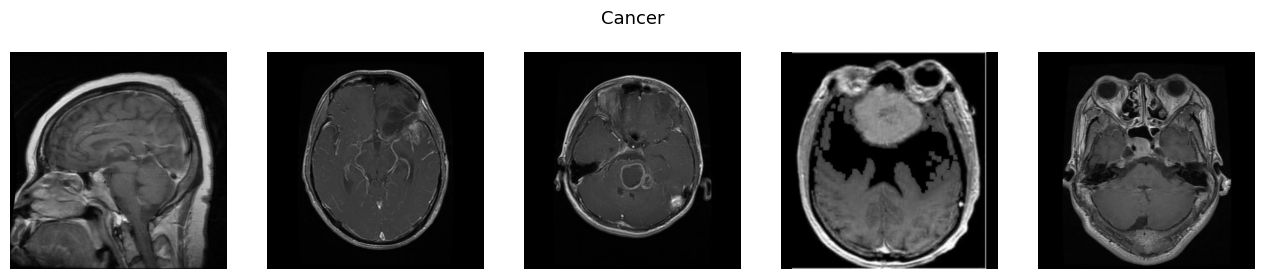

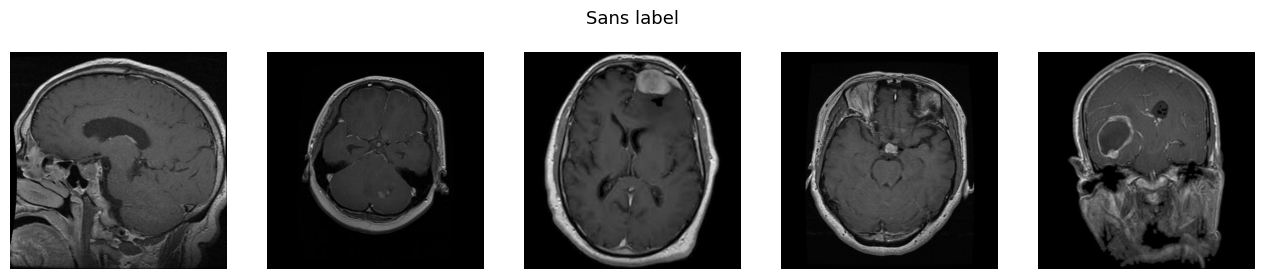

In [7]:
def show_samples(paths, title, n=5):
    paths = list(paths)[:n]
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 2.8))
    for ax, p in zip(axes, paths):
        ax.imshow(Image.open(p))
        ax.axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

show_samples(df[df.label == "normal"]["path"], "Normal")
show_samples(df[df.label == "cancer"]["path"], "Cancer")
show_samples(df[df.split == "unlabeled"]["path"], "Sans label")